# Deterministic UMAP Parameter Exploration

Compare four historical Hyrax UMAPs with fixed-seed controls and parameter variants. New embeddings are stored separately under `umap_explorations`; existing `runN/udbN_E` artifacts are never changed.

The reported trustworthiness and neighbor-retention values assess how faithfully the 2D projection preserves neighborhoods from the inference vectors. They do **not** establish whether the learned representation is scientifically or semantically good.

## 1. Environment and imports

Set the profile before importing `research_paths`. On Delta this defaults to `delta`; set `HYRAX_PROFILE=local` before starting the kernel to use the local fixture instead.

In [1]:
import os
from pathlib import Path

PROFILE = os.environ.get("HYRAX_PROFILE", "delta")
os.environ["HYRAX_PROFILE"] = PROFILE

from IPython.display import display

from research_paths import paths
from umap_parameter_explorer import (
    ExperimentRef,
    UmapParams,
    artifacts_table,
    build_merger_time_overlay,
    diagnose_runs,
    ensure_controls,
    evaluate_visualizer_selection,
    historical_runs,
    manifest_table,
    open_visualizer,
    plot_grid,
    plot_selection_results,
    preflight,
    run_parameter_sweep,
    runs_table,
    selection_results_table,
    session_directory,
)

print(f"Profile: {paths.profile}")
print(f"Run root: {paths.hyrax_runs}")
print(f"Exploration root: {paths.umap_explorations}")

Profile: delta
Run root: /work/hdd/bemi/dmiura/data_downloads/tng100_snap72/hyrax_runs
Exploration root: /work/hdd/bemi/dmiura/data_downloads/tng100_snap72/hyrax_runs/results/umap_explorations


## 2. Choose experiments and a session

Replace these four `(run, expt)` pairs with the experiments you want to inspect. Keep the same session name to reuse identical completed variants; change it when you want a separate exploration.

In [2]:
if PROFILE == "local":
    EXPERIMENTS = [ExperimentRef(run=1, expt=expt) for expt in range(1, 5)]
else:
    EXPERIMENTS = [
        ExperimentRef(run=11, expt=1),
        ExperimentRef(run=11, expt=2),
        ExperimentRef(run=11, expt=7),
        ExperimentRef(run=11, expt=8),
    ]

SESSION = os.environ.get("UMAP_EXPLORATION_SESSION", "umap_parameter_sweep_01")
RANDOM_SEED = 42
EVALUATION_SIZE = 2_000
DIAGNOSTIC_K = 15
OUTPUT_ROOT = Path(os.environ.get("UMAP_EXPLORATION_ROOT", paths.umap_explorations))
SESSION_DIR = session_directory(OUTPUT_ROOT, SESSION)

print(f"Session directory: {SESSION_DIR}")

Session directory: /work/hdd/bemi/dmiura/data_downloads/tng100_snap72/hyrax_runs/results/umap_explorations/umap_parameter_sweep_01


## 3. Preflight

Resolve every UDB config/log, inference directory, and historical 2D UMAP before writing anything. Parameters absent from an older config resolve to UMAP defaults (`min_dist=0.1`, `metric='euclidean'`).

In [3]:
artifacts = preflight(EXPERIMENTS, paths.hyrax_runs)
display(artifacts_table(artifacts))

,run,expt,config,log,inference_dir,historical_umap_dir,n_neighbors,min_dist,metric,n_components,fit_sample_size,batch_size
0,11,1,/work/hdd/bemi/dmiura/data_downloads/tng100_sn...,/work/hdd/bemi/dmiura/data_downloads/tng100_sn...,/work/hdd/bemi/dmiura/data_downloads/tng100_sn...,/work/hdd/bemi/dmiura/data_downloads/tng100_sn...,15,0.1,euclidean,2,5000,256
1,11,2,/work/hdd/bemi/dmiura/data_downloads/tng100_sn...,/work/hdd/bemi/dmiura/data_downloads/tng100_sn...,/work/hdd/bemi/dmiura/data_downloads/tng100_sn...,/work/hdd/bemi/dmiura/data_downloads/tng100_sn...,15,0.1,euclidean,2,5000,256
2,11,7,/work/hdd/bemi/dmiura/data_downloads/tng100_sn...,/work/hdd/bemi/dmiura/data_downloads/tng100_sn...,/work/hdd/bemi/dmiura/data_downloads/tng100_sn...,/work/hdd/bemi/dmiura/data_downloads/tng100_sn...,15,0.1,euclidean,2,5000,256
3,11,8,/work/hdd/bemi/dmiura/data_downloads/tng100_sn...,/work/hdd/bemi/dmiura/data_downloads/tng100_sn...,/work/hdd/bemi/dmiura/data_downloads/tng100_sn...,/work/hdd/bemi/dmiura/data_downloads/tng100_sn...,15,0.1,euclidean,2,5000,256


## 4. Historical overview

The historical UMAPs are referenced in place. Their old fit samples and random states were not recorded, so they are labeled `seed unknown`. Diagnostics use one fixed evaluation sample per experiment.

/u/dmiura/.conda/envs/hyrax311/lib/python3.11/site-packages/torch/cuda/__init__.py:65: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


,run,expt,label,result_dir,n_neighbors,min_dist,metric,n_components,seed,historical,reused,diagnostic_metric,evaluation_size,diagnostic_k,trustworthiness,knn_retention
0,11,1,historical (seed unknown),/work/hdd/bemi/dmiura/data_downloads/tng100_sn...,15,0.1,euclidean,2,None,True,False,euclidean,2000,15,0.802268,0.224733
1,11,2,historical (seed unknown),/work/hdd/bemi/dmiura/data_downloads/tng100_sn...,15,0.1,euclidean,2,None,True,False,euclidean,2000,15,0.802932,0.237033
2,11,7,historical (seed unknown),/work/hdd/bemi/dmiura/data_downloads/tng100_sn...,15,0.1,euclidean,2,None,True,False,euclidean,2000,15,0.946622,0.413633
3,11,8,historical (seed unknown),/work/hdd/bemi/dmiura/data_downloads/tng100_sn...,15,0.1,euclidean,2,None,True,False,euclidean,2000,15,0.992549,0.561867


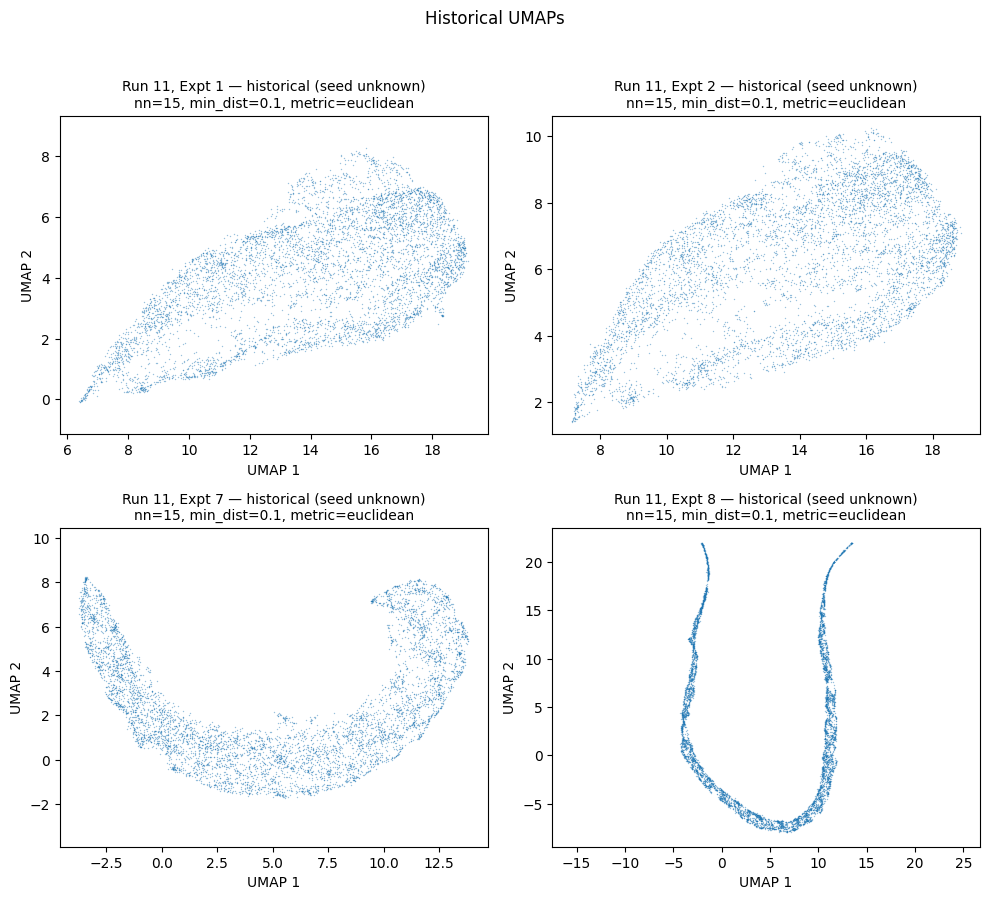

In [4]:
historical = historical_runs(artifacts)
plot_grid(historical, suptitle="Historical UMAPs", ncols=2)

historical = diagnose_runs(
    historical,
    output_root=OUTPUT_ROOT,
    session=SESSION,
    seed=RANDOM_SEED,
    evaluation_size=EVALUATION_SIZE,
    diagnostic_k=DIAGNOSTIC_K,
)
display(runs_table(historical))

## 5. Deterministic controls

Each control uses the experiment's historical parameter values, a fixed UMAP/transform seed, and a fixed fit sample whose size matches the source UDB config. The first execution computes results; later identical calls reuse them.

,run,expt,label,result_dir,n_neighbors,min_dist,metric,n_components,seed,historical,reused,diagnostic_k,diagnostic_metric,evaluation_size,knn_retention,trustworthiness
0,11,1,deterministic control,/work/hdd/bemi/dmiura/data_downloads/tng100_sn...,15,0.1,euclidean,2,42,False,True,15,euclidean,2000,0.218033,0.802891
1,11,2,deterministic control,/work/hdd/bemi/dmiura/data_downloads/tng100_sn...,15,0.1,euclidean,2,42,False,True,15,euclidean,2000,0.235500,0.802664
2,11,7,deterministic control,/work/hdd/bemi/dmiura/data_downloads/tng100_sn...,15,0.1,euclidean,2,42,False,True,15,euclidean,2000,0.412100,0.943393
3,11,8,deterministic control,/work/hdd/bemi/dmiura/data_downloads/tng100_sn...,15,0.1,euclidean,2,42,False,True,15,euclidean,2000,0.555800,0.992407


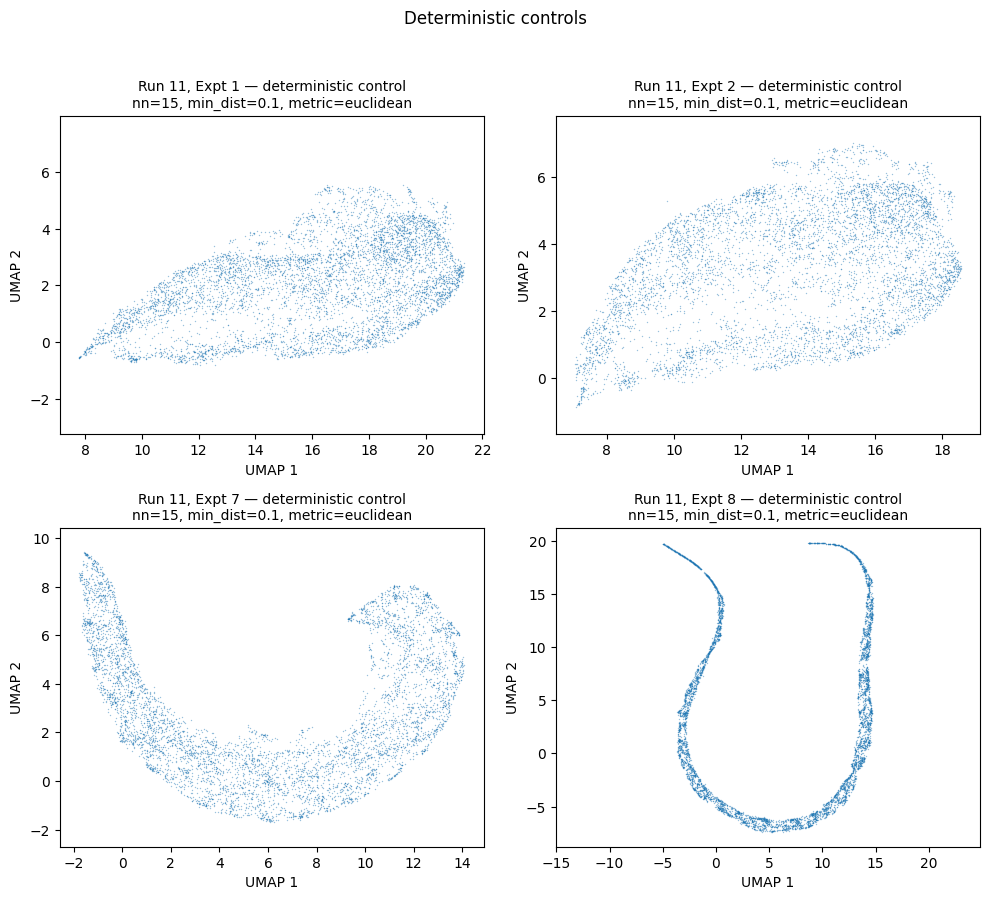

In [5]:
controls = ensure_controls(
    artifacts,
    output_root=OUTPUT_ROOT,
    session=SESSION,
    seed=RANDOM_SEED,
    evaluation_size=EVALUATION_SIZE,
    diagnostic_k=DIAGNOSTIC_K,
)
plot_grid(controls, suptitle="Deterministic controls", ncols=2)
display(runs_table(controls))

(<Figure size 1000x1800 with 8 Axes>,
 array([[<Axes: title={'center': 'Run 11, Expt 1 — historical (seed unknown)\nnn=15, min_dist=0.1, metric=euclidean'}, xlabel='UMAP 1', ylabel='UMAP 2'>,
         <Axes: title={'center': 'Run 11, Expt 1 — deterministic control\nnn=15, min_dist=0.1, metric=euclidean'}, xlabel='UMAP 1', ylabel='UMAP 2'>],
        [<Axes: title={'center': 'Run 11, Expt 2 — historical (seed unknown)\nnn=15, min_dist=0.1, metric=euclidean'}, xlabel='UMAP 1', ylabel='UMAP 2'>,
         <Axes: title={'center': 'Run 11, Expt 2 — deterministic control\nnn=15, min_dist=0.1, metric=euclidean'}, xlabel='UMAP 1', ylabel='UMAP 2'>],
        [<Axes: title={'center': 'Run 11, Expt 7 — historical (seed unknown)\nnn=15, min_dist=0.1, metric=euclidean'}, xlabel='UMAP 1', ylabel='UMAP 2'>,
         <Axes: title={'center': 'Run 11, Expt 7 — deterministic control\nnn=15, min_dist=0.1, metric=euclidean'}, xlabel='UMAP 1', ylabel='UMAP 2'>],
        [<Axes: title={'center': 'Run 11, Expt 

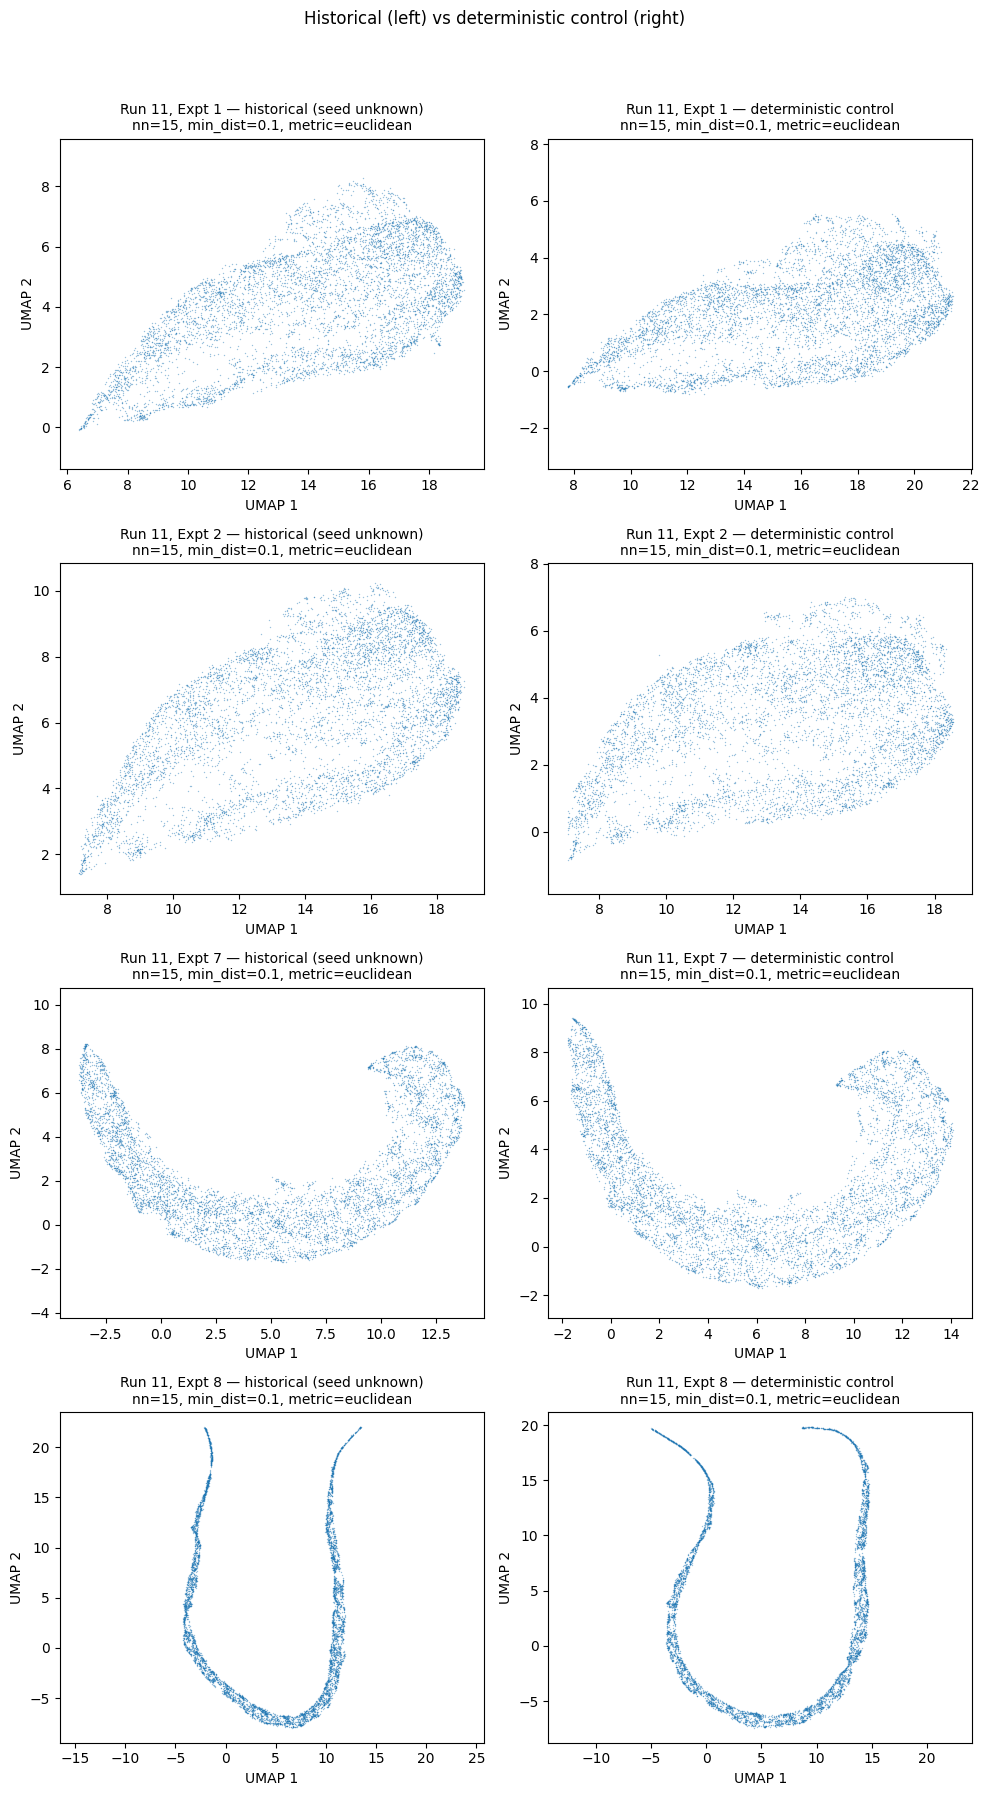

In [7]:
historical_vs_control = [
    run
    for ref in EXPERIMENTS
    for run in (historical[ref], controls[ref])
]
plot_grid(
    historical_vs_control,
    suptitle="Historical (left) vs deterministic control (right)",
    ncols=2,
)

## 6. Focused one-parameter sweeps

Choose one focused experiment below. Each sweep starts from that experiment's recorded historical parameters and changes exactly one parameter; `n_components` remains fixed at 2. The baseline value is included in every comparison.

The three sweep cells are independent, so run only the comparison you want. They execute their values sequentially and may take a while on Delta. Completed values are cached on disk, and rerunning a cell reuses them.

In [9]:
FOCUS_EXPERIMENT = ExperimentRef(run=11, expt=8)
if FOCUS_EXPERIMENT not in artifacts:
    raise KeyError(f"{FOCUS_EXPERIMENT} is not present in EXPERIMENTS")

BASELINE_PARAMS = artifacts[FOCUS_EXPERIMENT].original_params
print(f"Focused experiment: {FOCUS_EXPERIMENT.key}")
print(f"Historical baseline: {BASELINE_PARAMS}")

### 6a. Sweep `n_neighbors`

This keeps `min_dist` and `metric` at the historical baseline. Lower values emphasize local structure; higher values emphasize broader neighborhoods.

run11_expt8: transform:   0%|          | 0/24 [00:00<?, ?it/s]

,run,expt,label,result_dir,n_neighbors,min_dist,metric,n_components,seed,historical,reused,diagnostic_metric,evaluation_size,diagnostic_k,trustworthiness,knn_retention
0,11,8,parameter variant,/work/hdd/bemi/dmiura/data_downloads/tng100_sn...,30,0.1,euclidean,2,42,False,False,euclidean,2000,15,0.992318,0.547867


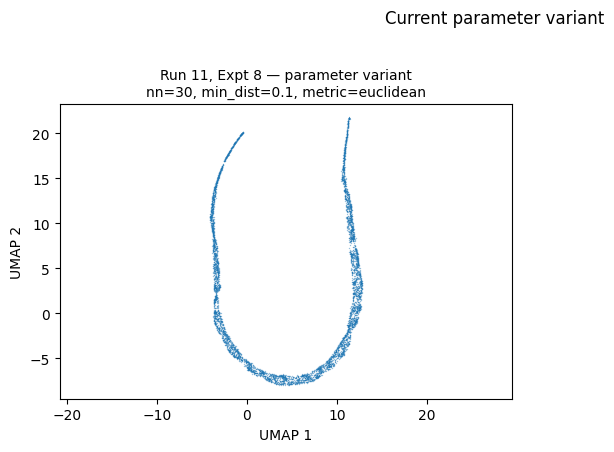

In [10]:
# n_neighbors sweep: all other settings remain at the historical baseline.
NN_VALUES = sorted({5, 10, 15, 30, 50, 100, BASELINE_PARAMS.n_neighbors})

n_neighbors_sweep = run_parameter_sweep(
    artifacts[FOCUS_EXPERIMENT],
    "n_neighbors",
    NN_VALUES,
    baseline_params=BASELINE_PARAMS,
    output_root=OUTPUT_ROOT,
    session=SESSION,
    seed=RANDOM_SEED,
    evaluation_size=EVALUATION_SIZE,
    diagnostic_k=DIAGNOSTIC_K,
)
plot_grid(
    n_neighbors_sweep,
    suptitle=f"{FOCUS_EXPERIMENT.key}: n_neighbors sweep",
    ncols=3,
)
display(runs_table(n_neighbors_sweep))

### 6b. Sweep `min_dist`

This keeps `n_neighbors` and `metric` at the historical baseline. Lower values permit tighter clumps; higher values force nearby points to spread out.

In [ ]:
MIN_DIST_VALUES = sorted({0.0, 0.05, 0.1, 0.25, 0.5, 0.8, BASELINE_PARAMS.min_dist})

min_dist_sweep = run_parameter_sweep(
    artifacts[FOCUS_EXPERIMENT],
    "min_dist",
    MIN_DIST_VALUES,
    baseline_params=BASELINE_PARAMS,
    output_root=OUTPUT_ROOT,
    session=SESSION,
    seed=RANDOM_SEED,
    evaluation_size=EVALUATION_SIZE,
    diagnostic_k=DIAGNOSTIC_K,
)
plot_grid(
    min_dist_sweep,
    suptitle=f"{FOCUS_EXPERIMENT.key}: min_dist sweep",
    ncols=3,
)
display(runs_table(min_dist_sweep))

### 6c. Sweep `metric`

This keeps `n_neighbors` and `min_dist` at the historical baseline. These four metrics are useful starting points for latent vectors; UMAP validates each name during fitting.

In [ ]:
METRIC_VALUES = list(dict.fromkeys([
    "euclidean",
    "cosine",
    "correlation",
    "manhattan",
    BASELINE_PARAMS.metric,
]))

metric_sweep = run_parameter_sweep(
    artifacts[FOCUS_EXPERIMENT],
    "metric",
    METRIC_VALUES,
    baseline_params=BASELINE_PARAMS,
    output_root=OUTPUT_ROOT,
    session=SESSION,
    seed=RANDOM_SEED,
    evaluation_size=EVALUATION_SIZE,
    diagnostic_k=DIAGNOSTIC_K,
)
plot_grid(
    metric_sweep,
    suptitle=f"{FOCUS_EXPERIMENT.key}: metric sweep",
    ncols=2,
)
display(runs_table(metric_sweep))

## 7. Focused interactive visualization with a merger overlay

Open any historical, control, or sweep result through the existing Hyrax `visualize` verb. Choose `MERGER_TYPE` from `mini`, `minor`, or `major`, and set the inclusive maximum time since merger in Gyr. Rerun the cell after changing either value.

Set `SHOW_MERGER_OVERLAY=False` to hide the markers while retaining the same target rule for a blind completeness-purity evaluation. Scores from a lasso drawn while the overlay is visible are descriptive and potentially optimistic.

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
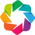

BokehModel(combine_events=True, render_bundle={'docs_json': {'7601f443-90e4-4e5f-90b8-d15ea7610b56': {'version…

In [11]:
import static_umap_metrics as selection_metrics

selection_metrics.init_tabular_stack()
selection_context = selection_metrics.load_path_context(profile=PROFILE)
selection_catalog = selection_metrics.load_sample_catalog(selection_context, name="all")
selection_overlay_groups = selection_metrics.build_default_overlay_groups(selection_catalog)

FOCUS_RUN = controls[FOCUS_EXPERIMENT]
# FOCUS_RUN = historical[FOCUS_EXPERIMENT]
# FOCUS_RUN = n_neighbors_sweep[30]
# FOCUS_RUN = min_dist_sweep[0.05]
# FOCUS_RUN = metric_sweep["cosine"]

MERGER_TYPE = "major"       # "mini", "minor", or "major"
MERGER_MAX_GYR = 1.0        # Inclusive: 0 <= time since merger <= this value
SHOW_MERGER_OVERLAY = True  # Set False before drawing a blind validation lasso

MERGER_OVERLAY = build_merger_time_overlay(
    FOCUS_RUN,
    selection_catalog,
    MERGER_TYPE,
    MERGER_MAX_GYR,
)
INTERACTIVE_OVERLAYS = (
    [MERGER_OVERLAY.visualizer_overlay]
    if SHOW_MERGER_OVERLAY
    else None
)
print(
    f"{MERGER_OVERLAY.label}: "
    f"{MERGER_OVERLAY.n_umap_targets:,} targets in {FOCUS_RUN.artifact.ref.key} "
    f"({MERGER_OVERLAY.n_catalog_targets:,} unique catalog targets)"
)
print(f"Overlay visible: {SHOW_MERGER_OVERLAY}")

pane, viz = open_visualizer(
    FOCUS_RUN,
    display_images=True,
    overlays=INTERACTIVE_OVERLAYS,
    width=550,
    height=550,
)

## 8. Manual selection completeness and purity

Use the lasso tool to draw an ellipse-like region on the interactive UMAP above. Each lasso is one operating point: **completeness** is the fraction of all known targets captured by the selection, while **purity** is the fraction of selected objects with known labels that are targets. Objects with missing or unmatched labels are excluded from both denominators and reported through the selected-label coverage columns.

For an unbiased validation check, draw the region without showing the target labels. If the target overlay influenced the selection, interpret the result as descriptive and potentially optimistic.

In [12]:
# By default, score the exact merger type and cutoff configured above.
TARGET_RULES = [MERGER_OVERLAY.target_rule]

# To restore the original major/minor/mini past-1-Gyr flag comparison, use:
# TARGET_RULES = selection_overlay_groups["recent_merger_flags"]

display(selection_metrics.summarize_overlays(selection_catalog, TARGET_RULES))

Loaded sample catalog 'all': 30,395 rows from /work/hdd/bemi/dmiura/data_downloads/tng100_snap72/split_images/catalog2.fits


,label,key,selected_catalog_rows,selected_min,selected_median,selected_max
0,Major past 1 Gyr,has_major_past_1gyr,1620,1.0,1.0,1.0
1,Minor past 1 Gyr,has_minor_past_1gyr,1460,1.0,1.0,1.0
2,Mini past 1 Gyr,has_mini_past_1gyr,7765,1.0,1.0,1.0


The list below is deliberately in memory only. To compare another UMAP, assign that result to `FOCUS_RUN`, rerun the interactive visualization cell, draw a new lasso, give it a unique `SELECTION_NAME`, and rerun the scoring cell.

In [13]:
selection_evaluations = []

After drawing a lasso, name and score it below. Re-running this cell appends another evaluation. The selected-object table is long-form: each selected object appears once for every target rule.

In [14]:
if len(viz.points_id) == 0:
    raise ValueError(
        "No UMAP points are selected. Use the lasso-select tool, draw a region, "
        "and confirm that the table beside the UMAP updates before scoring."
    )
print(f"Selected UMAP points: {len(viz.points_id):,}")

SELECTION_NAME = (
    f"run{FOCUS_RUN.artifact.ref.run}_expt{FOCUS_RUN.artifact.ref.expt}"
    " candidate region 1"
)
selection_evaluation = evaluate_visualizer_selection(
    FOCUS_RUN,
    viz,
    selection_catalog,
    TARGET_RULES,
    selection_name=SELECTION_NAME,
)
selection_evaluations.append(selection_evaluation)

display(selection_evaluation.summary)
display(selection_evaluation.selected_objects)

,selection_name,run,expt,umap_label,result_dir,n_neighbors,min_dist,metric,seed,historical,...,n_selected_unknown,selected_label_coverage,true_positives,false_positives,false_negatives,true_negatives,completeness,purity,f1,lift
0,run11_expt1 candidate region 1,11,1,parameter variant,/work/hdd/bemi/dmiura/data_downloads/tng100_sn...,30,0.05,cosine,42,False,...,0,1.0,71,311,253,5444,0.219136,0.185864,0.201133,3.487242
1,run11_expt1 candidate region 1,11,1,parameter variant,/work/hdd/bemi/dmiura/data_downloads/tng100_sn...,30,0.05,cosine,42,False,...,0,1.0,59,323,233,5464,0.202055,0.154450,0.175074,3.215422
2,run11_expt1 candidate region 1,11,1,parameter variant,/work/hdd/bemi/dmiura/data_downloads/tng100_sn...,30,0.05,cosine,42,False,...,0,1.0,210,172,1343,4354,0.135222,0.549738,0.217054,2.151873


,selection_name,run,expt,umap_label,result_dir,n_neighbors,min_dist,metric,seed,historical,object_id,x,y,filename_data,umap_index,target_label,target_key,is_known_label,is_target
0,run11_expt1 candidate region 1,11,1,parameter variant,/work/hdd/bemi/dmiura/data_downloads/tng100_sn...,30,0.05,cosine,42,False,72098456,43.754475,-10.718321,b'100_72_98456_G_v2_hsc_realistic.fits',682,Major past 1 Gyr,has_major_past_1gyr,True,False
1,run11_expt1 candidate region 1,11,1,parameter variant,/work/hdd/bemi/dmiura/data_downloads/tng100_sn...,30,0.05,cosine,42,False,72098456,43.754475,-10.718321,b'100_72_98456_G_v2_hsc_realistic.fits',682,Minor past 1 Gyr,has_minor_past_1gyr,True,False
2,run11_expt1 candidate region 1,11,1,parameter variant,/work/hdd/bemi/dmiura/data_downloads/tng100_sn...,30,0.05,cosine,42,False,72098456,43.754475,-10.718321,b'100_72_98456_G_v2_hsc_realistic.fits',682,Mini past 1 Gyr,has_mini_past_1gyr,True,False
3,run11_expt1 candidate region 1,11,1,parameter variant,/work/hdd/bemi/dmiura/data_downloads/tng100_sn...,30,0.05,cosine,42,False,72136209,44.092308,-10.854859,b'100_72_136209_G_v2_hsc_realistic.fits',920,Major past 1 Gyr,has_major_past_1gyr,True,False
4,run11_expt1 candidate region 1,11,1,parameter variant,/work/hdd/bemi/dmiura/data_downloads/tng100_sn...,30,0.05,cosine,42,False,72136209,44.092308,-10.854859,b'100_72_136209_G_v2_hsc_realistic.fits',920,Minor past 1 Gyr,has_minor_past_1gyr,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1141,run11_expt1 candidate region 1,11,1,parameter variant,/work/hdd/bemi/dmiura/data_downloads/tng100_sn...,30,0.05,cosine,42,False,72026681,43.767742,-8.772379,b'100_72_26681_G_v2_hsc_realistic.fits',182,Minor past 1 Gyr,has_minor_past_1gyr,True,True
1142,run11_expt1 candidate region 1,11,1,parameter variant,/work/hdd/bemi/dmiura/data_downloads/tng100_sn...,30,0.05,cosine,42,False,72026681,43.767742,-8.772379,b'100_72_26681_G_v2_hsc_realistic.fits',182,Mini past 1 Gyr,has_mini_past_1gyr,True,True
1143,run11_expt1 candidate region 1,11,1,parameter variant,/work/hdd/bemi/dmiura/data_downloads/tng100_sn...,30,0.05,cosine,42,False,72156715,43.778107,-8.560225,b'100_72_156715_G_v2_hsc_realistic.fits',1069,Major past 1 Gyr,has_major_past_1gyr,True,False
1144,run11_expt1 candidate region 1,11,1,parameter variant,/work/hdd/bemi/dmiura/data_downloads/tng100_sn...,30,0.05,cosine,42,False,72156715,43.778107,-8.560225,b'100_72_156715_G_v2_hsc_realistic.fits',1069,Minor past 1 Gyr,has_minor_past_1gyr,True,True


,selection_name,run,expt,umap_label,result_dir,n_neighbors,min_dist,metric,seed,historical,...,n_selected_unknown,selected_label_coverage,true_positives,false_positives,false_negatives,true_negatives,completeness,purity,f1,lift
0,run11_expt1 candidate region 1,11,1,parameter variant,/work/hdd/bemi/dmiura/data_downloads/tng100_sn...,30,0.05,cosine,42,False,...,0,1.0,71,311,253,5444,0.219136,0.185864,0.201133,3.487242
1,run11_expt1 candidate region 1,11,1,parameter variant,/work/hdd/bemi/dmiura/data_downloads/tng100_sn...,30,0.05,cosine,42,False,...,0,1.0,59,323,233,5464,0.202055,0.154450,0.175074,3.215422
2,run11_expt1 candidate region 1,11,1,parameter variant,/work/hdd/bemi/dmiura/data_downloads/tng100_sn...,30,0.05,cosine,42,False,...,0,1.0,210,172,1343,4354,0.135222,0.549738,0.217054,2.151873


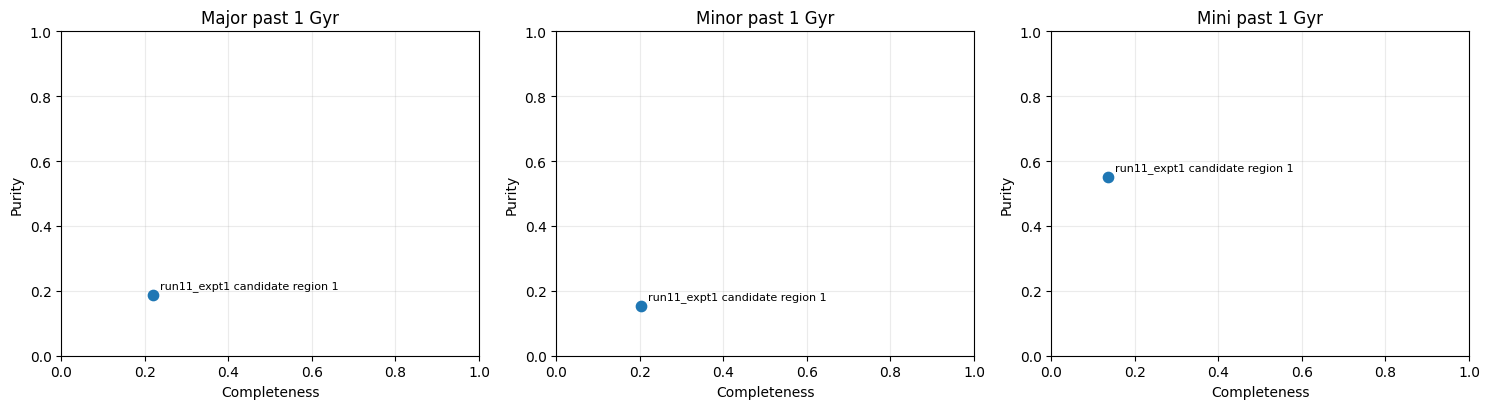

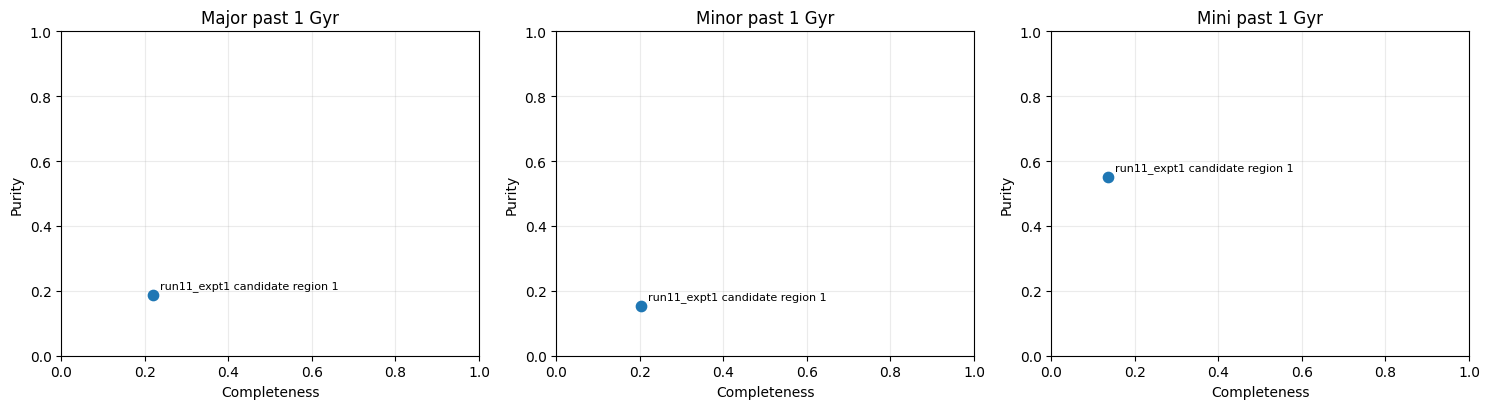

In [15]:
selection_comparison = selection_results_table(selection_evaluations)
display(selection_comparison)
selection_figure, selection_axes = plot_selection_results(selection_evaluations)
selection_figure

## 9. Manifest and cache reuse

The manifest is rebuilt from completed per-result `provenance.json` files. Repeating the same source, sample, parameters, seed, and package-version combination returns the existing directory rather than creating another copy.

In [ ]:
session_manifest = manifest_table(SESSION_DIR)
focused_manifest = session_manifest.loc[
    (session_manifest["run"] == FOCUS_EXPERIMENT.run)
    & (session_manifest["expt"] == FOCUS_EXPERIMENT.expt)
].sort_values(["metric", "n_neighbors", "min_dist"])
display(focused_manifest)
print("Rerun any sweep cell to reuse its completed parameter combinations.")

## Interpretation reminders

- Vary one parameter at a time first. Lower `n_neighbors` emphasizes local structure; higher values emphasize broader structure.
- Lower `min_dist` permits tighter clumps; higher values spread nearby points out.
- Changing `metric` changes what counts as near in the inference space, so compare both the plot and the diagnostics.
- A manual lasso contributes one completeness-purity point; a collection of hand-drawn selections is a comparison of operating points, not a threshold-generated curve.
- Stable, high-fidelity 2D structure across reasonable settings is evidence that the display is not merely a fragile UMAP accident. It still does not prove the training objective learned the scientific distinctions you care about; that requires labels, overlays, or a downstream validation task.